# MDTF ESNB Notebook: North Atlantic Ocean POD

Runs the `natl_ocean` POD (Maroon et al., `emaroon/cmip_input_noamoc` branch) through the ESNB interface on CESM2 historical r1i1p1f1.

Validated end-to-end 2026-04-22 with:
- 2 yrs (1980–1981) of CESM2 monthly ocean data from `/glade/collections/cmip/CMIP6/…`
- Obs: `/glade/campaign/cgd/ccr/yeager/Sub2Sub/POD_data/obs_1x1.nc` (symlinked into `inputdata/obs_data/natl_ocean/`)

**Kernel:** `Python (esnb)` (set via the top-right kernel selector).

In [2]:
%load_ext autoreload
%autoreload 2

import os, sys, copy, json
from pathlib import Path
import xarray as xr

os.environ['CODE_ROOT'] = '/glade/work/taydral/MDTF/MDTF-diagnostics'
os.environ['WORK_DIR']  = '/glade/work/taydral/MDTF/wkdir/MDTF_output/natl_ocean'
os.environ['OBS_DATA']  = '/glade/work/taydral/MDTF/inputdata/obs_data/natl_ocean/'
Path(os.environ['WORK_DIR']).mkdir(parents=True, exist_ok=True)

## About the POD: North Atlantic Ocean diagnostics

This POD evaluates how well climate models represent the subtropical-to-subpolar North Atlantic
ocean state, focusing on:
- Sea surface and upper-200m temperature and salinity climatologies
- Mixed layer depth (MLD)
- Potential density (σ₀)
- Surface heat and freshwater fluxes
- Bias relative to a 1°×1° observation-based reference (`obs_1x1.nc`)

------------------------------------------
- POD source: `diagnostics/natl_ocean/` (Maroon et al., `emaroon/cmip_input_noamoc` branch)
- Helper module: `POD_utils.py`
- Detailed description: `diagnostics/natl_ocean/doc/natl_ocean.rst`
- **Note:** The AMOC/WMT portion of the POD is not yet working upstream; this notebook covers
  the bias / climatology portion only.
  
-------------------------------------------

## Jupyter ESNB notebook POD settings
- Need to add more documentation and examples
- This pod requires {add vars and resolution}
The POD is built upon the following procedures:
### [Section 1: Prepare POD Settings](#section1)
- Set the parameters of the POD (interactive or read from `settings.jsonc`)
- Set the runtime configurations
- Define the model case (CESM2 historical r1i1p1f1) and date range
- Point at the data catalog and obs / work directories
### [Section 2: Load Data from Catalog Files](#section2)
- ESNB option for the monthly variables
- Manual `xr.open_dataset` for fx (time-invariant) variables
- Merge into a single dataset and load obs
### [Section 3: Diagnostics Computation](#section3)
- Sanity check: compute σ₀ on a small slice
- Steps 1–5: bias-plot path (preprocess, σ₀/MLD, zavg, regrid, climatology)
- Steps 6–7: WMT path (surface fields → `compute_wmt` lines + maps)
### [Section 4: Results Visualization](#section4)
- Bias maps vs obs (θ, S, σ₀, MLD)
- Scatter plot of θ vs S biases
- WMT lines vs OMIP benchmarks (by region)
- Density-flux maps at specified σ₂ classes

<a id='section1'></a>
## Section 1: Prepare POD Settings

Load from `diagnostics/natl_ocean/settings.jsonc` (`mode == "prod"`) or define inline (`mode == "interactive"`).
We also build a monthly-only copy for ESNB — it can't time-slice the fx vars (`areacello`, `volcello`),
so we load those manually in Section 3.

In [3]:
# Framework: Setup paths to import MDTF code as modules
module_path = os.environ['CODE_ROOT']
print(f"Using MDTF framework version {module_path}")
if module_path not in sys.path:
    sys.path.append(module_path)

# Import python libraries from /src directory
from src import util              # varlist_util, translation, xr_parser, units
from src.util import json_utils

Using MDTF framework version /glade/work/taydral/MDTF/MDTF-diagnostics


 If the mode is `interactive`, the user will manually input the needed info of the POD options, otherwise the info will be read from the default `settings.jsonc` file.

In [4]:
# Define a mode (leave "interactive" for now; "prod" reads settings.jsonc)
mode = "interactive"

# machine: controls whether to spin up a dask PBSCluster.
#   "casper"        — submit a PBS job and use dask-distributed for parallel compute
#   "casper-notdask" — single-process xarray/dask (default; what the rest of the notebook
#                      has been tested against)
#machine = "casper-notdask"
machine = "casper"

# Verbosity
verbose = True

### Optional: spin up a dask PBSCluster on Casper

Set `machine = "casper"` in the previous cell to submit a PBS job and use `dask.distributed` for parallel compute. The cluster takes a minute or two to start (check `qstat -u $USER` from a terminal). Set `machine = "casper-notdask"` to skip and stay single-process. Pattern mirrors `blocking_main_esnb.ipynb`.

In [5]:
# Machine-specific dask setup. Casper PBS via dask-jobqueue.
client = None
cluster = None

if machine == "casper":
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client

    cluster = PBSCluster(
        cores=4,
        memory="8GB",
        account="UWIS0041",
        interface="ext",
        job_extra_directives=[],
        walltime="2:00:00",
        queue="casper",
        resource_spec="select=1:ncpus=4:mem=8GB",
    )
    cluster.scale(jobs=1)
    client = Client(cluster)
    print('dask client:', client)
    print('dashboard:', client.dashboard_link)
    # Note: cluster starts via PBS queue — `qstat -u $USER` in a terminal to monitor.
else:
    print(f'machine={machine!r} — skipping dask cluster setup')

dask client: <Client: 'tcp://128.117.208.174:37555' processes=0 threads=0, memory=0 B>
dashboard: http://128.117.208.174:8787/status


In [ ]:
cluster.close()
client.close()

### POD settings are defined here (interactive mode) or read from the settings.jsonc file
- settings_dict stores the information needed to run the POD
- If it's interactive mode, user needs to enter each information manually
- Otherwise it can be read in from a settings.jsonc file
- The user can change the time period, latitude range, number of workers
- AdvUser: feel free to define own parameters

In [6]:
startdate, enddate = '1980-01-01', '1981-12-31'

if mode == "interactive":
    settings_full = {
        "settings": {
            # pod_options — natl_ocean-specific knobs (not read by MDTF framework)
            "pod_options": {
                "start_date":    startdate,
                "end_date":      enddate,
                # POD_utils.compute_zavg upper-ocean depth (m)
                "zavg_depth":    200,
                # POD_utils.compute_mld density threshold (kg/m^3) and reference depth (m)
                "mld_dsig":      0.03,
                "mld_rdep":      10.0,
                # POD_utils.regrid target grid (deg) and method
                "regrid_dlon":   1,
                "regrid_dlat":   1,
                "regrid_method": "bilinear",
                # POD_utils.SpatialPlot_climo_bias map region [lon_min, lon_max, lat_min, lat_max]
                "plot_region":   [270, 360, 20, 80],
                "focus_region":  [312, 330, 38, 53],
                "plot_month":    13,   # 13 = annual mean
                "num_workers":   8,
                # WMT (Section 3 Step 6+ / Section 4)
                "wmt_sigma_classes": [35.0, 36.0, 36.5],  # sigma2 levels for compute_wmt MAPS
                "wmt_dsigma":         0.1,                # sigma2 bin width
                "wmt_lat_max":        44,                 # cut to <=lat_max for SPNA WMT
            },
            "runtime_requirements": {"python3": ["matplotlib", "xarray", "xesmf"]},
            "driver":      "natl_driver.py",
            "long_name":   "North Atlantic diagnostic in Subtropical to Subpolar latitudes",
            "convention":  "CMIP",
            "description": "North Atlantic Ocean diagnostics",
        },
        "dimensions": {
            "nlat": {"standard_name": "latitude",  "units": "degrees_north", "axis": "Y"},
            "nlon": {"standard_name": "longitude", "units": "degrees_east", "axis": "X"},
            "lev":  {"standard_name": "depth", "units": "centimeters", "axis": "Z", "positive": "down"},
            "time": {"standard_name": "time"},
        },
        "varlist": {
            "tos":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","nlat","nlon"],        "standard_name": "sea_surface_temperature",                  "units": "degC"},
            "vsf":       {"frequency": "month", "realm": "ocean", "dimensions": ["time","nlat","nlon"],        "standard_name": "virtual_salt_flux_into_sea_water",         "units": "kg m-2 s-1"},
            "hfds":      {"frequency": "month", "realm": "ocean", "dimensions": ["time","nlat","nlon"],        "standard_name": "surface_downward_heat_flux_in_sea_water",  "units": "W m-2"},
            "so":        {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_salinity",                       "units": "psu"},
            "thetao":    {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_potential_temperature",          "units": "degC"},
            "uo":        {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_x_velocity",                       "units": "m s-1"},
            "vo":        {"frequency": "month", "realm": "ocean", "dimensions": ["time","lev","nlat","nlon"], "standard_name": "sea_water_y_velocity",                       "units": "m s-1"},
            "volcello":  {"realm": "ocean", "dimensions": ["lev","nlat","nlon"], "standard_name": "ocean_volume", "units": "m3"},
            "areacello": {"realm": "ocean", "dimensions": ["nlat","nlon"],       "standard_name": "cell_area",    "units": "m2"},
        },
    }
else:  # prod mode: read from settings.jsonc (no pod_options block)
    settings_file_path = os.path.join(module_path, "diagnostics/natl_ocean/settings.jsonc")
    try:
        settings_full = json_utils.read_json(settings_file_path)
    except Exception as e:
        print(f"An unexpected error occurred when reading the JSONC file: {e}")

# POD-specific: build a monthly-only copy for ESNB.
# ESNB tries to time-slice every loaded variable; the fx vars (areacello, volcello)
# have no time dim and break .open(). They are loaded manually in Section 3.
settings_monthly = copy.deepcopy(settings_full)
for fx_var in ('areacello', 'volcello'):
    settings_monthly['varlist'].pop(fx_var, None)

print('varlist (ESNB):', list(settings_monthly['varlist'].keys()))
print('varlist (full):', list(settings_full['varlist'].keys()))

varlist (ESNB): ['tos', 'vsf', 'hfds', 'so', 'thetao', 'uo', 'vo']
varlist (full): ['tos', 'vsf', 'hfds', 'so', 'thetao', 'uo', 'vo', 'volcello', 'areacello']


### The runtime configuration is defined here (interactive mode) or read from the runtime_config.yml file

Defines which simulation(s) to pull from the catalog, the date range, and output paths.

- If running in interactive mode, case settings are entered inline below.
- Otherwise they can be read from a `runtime_config.yml`-style file (not used here).

In [7]:
if mode == "interactive":
    case_info = {
        "case_list": {
            "CESM2_historical_r1i1p1f1": {
                "model": "CESM", "convention": "CMIP",
                "startdate": startdate, "enddate": enddate,
            }
        },
        "DATA_CATALOG":   str(Path(module_path) / "diagnostics/natl_ocean/CMIP_CESM_historical_001.json"),
        "OBS_DATA_ROOT":  "/glade/work/taydral/MDTF/inputdata/obs_data",
        "WORK_DIR":       os.environ["WORK_DIR"],
        "OUTPUT_DIR":     os.environ["WORK_DIR"],
        "conda_root":     "/glade/u/home/taydral/miniconda3",
        "conda_env_root": "/glade/u/home/taydral/miniconda3/envs",
        "micromamba_exe": "", "large_file": False,
        "make_multicase_figure_html": False, "make_variab_tar": False,
        "overwrite": True, "pod_list": ["natl_ocean"],
        "run_pp": True, "save_pp_data": True, "save_ps": False,
        "translate_data": True, "user_pp_scripts": [""],
    }
else:
    # natl_ocean doesn't ship a runtime_config.yml; if you wire one up, load it here.
    case_input_file = os.path.join(module_path, "runtime_config_casper.jsonc")
    print(f"Reading case info from {case_input_file}")
    case_info = json_utils.read_json(case_input_file)

print(f"Catalog: {case_info['DATA_CATALOG']} (exists: {Path(case_info['DATA_CATALOG']).exists()})")

Catalog: /glade/work/taydral/MDTF/MDTF-diagnostics/diagnostics/natl_ocean/CMIP_CESM_historical_001.json (exists: True)


<a id='section2'></a>
## Section 2: Load Data from Catalog Files

**NOTE**: The ESNB library and its functions are only used in this section. Currently only two functions are needed for this POD: `NotebookDiagnostic` and `CaseGroup2`. Users also have the option to use [intake-ESM](https://intake-esm.readthedocs.io/en/stable/) functions.
- There is an esnb/intake-esm difference that causes errors. Might need to update catalog builder for esnb catalog to include same column as intake-esm
- Overall: We should provide a catalog for time-slice experiments

In [8]:
# Import ESNB library and necessary functions
import esnb
from esnb import NotebookDiagnostic, CaseGroup2

### Initialize the diagnostic and an MDTF case

In [9]:
# Initialize the diagnostic
pod_env_vars = NotebookDiagnostic(settings_monthly)

# Initialize an MDTF case
groups = [
    CaseGroup2(
        case_info,
        date_range=(startdate, enddate),
    )
]

In [10]:
# Check that the case info is correct
groups[0]

source,"{'case_list': {'CESM2_historical_r1i1p1f1': {'model': 'CESM', 'convention': 'CMIP', 'startdate': '1980-01-01', 'enddate': '1981-12-31'}}, 'DATA_CATALOG': '/glade/work/taydral/MDTF/MDTF-diagnostics/diagnostics/natl_ocean/CMIP_CESM_historical_001.json', 'OBS_DATA_ROOT': '/glade/work/taydral/MDTF/inputdata/obs_data', 'WORK_DIR': '/glade/work/taydral/MDTF/wkdir/MDTF_output/natl_ocean', 'OUTPUT_DIR': '/glade/work/taydral/MDTF/wkdir/MDTF_output/natl_ocean', 'conda_root': '/glade/u/home/taydral/miniconda3', 'conda_env_root': '/glade/u/home/taydral/miniconda3/envs', 'micromamba_exe': '', 'large_file': False, 'make_multicase_figure_html': False, 'make_variab_tar': False, 'overwrite': True, 'pod_list': ['natl_ocean'], 'run_pp': True, 'save_pp_data': True, 'save_ps': False, 'translate_data': True, 'user_pp_scripts': ['']}"
date_range,"('1980-01-01', '1981-12-31')"
concat_dim,None
is_resolved,False
is_loaded,False
plot_color,None
cases,[CaseExperiment2(CESM2_historical_r1i1p1f1)]


In [11]:
# Combine the experiments with the diagnostic request and determine
# what files need to be loaded
pod_env_vars.resolve(groups)

In [12]:
# List the files that will be loaded
pod_env_vars.files

['/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Omon/hfds/gn/v20190308/hfds_Omon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc',
 '/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Omon/so/gn/v20190308/so_Omon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc',
 '/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Omon/thetao/gn/v20190308/thetao_Omon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc',
 '/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Omon/tos/gn/v20190308/tos_Omon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc',
 '/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Omon/uo/gn/v20190308/uo_Omon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc',
 '/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Omon/vo/gn/v20190308/vo_Omon_CESM2_historical_r1i1p1f1_gn_185001-201412.nc',
 '/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Omon/vsf/gn/v20190308/vsf_Omon_CESM2_historical_

In [13]:
# Open the files as xarray datasets
pod_env_vars.open()

/glade/u/home/taydral/miniconda3/envs/esnb/lib/python3.12/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'tos' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/glade/u/home/taydral/miniconda3/envs/esnb/lib/python3.12/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vsf' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/glade/u/home/taydral/miniconda3/envs/esnb/lib/python3.12/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'hfds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/glade/u/home/taydral/miniconda3/envs/esnb/lib/python3.12/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'so' has multiple fill values {np.float32(1e+20

In [14]:
print(f'Number of files loaded: {len(pod_env_vars.files)}')
pod_env_vars.datasets

Number of files loaded: 7


[<xarray.Dataset> Size: 14MB
 Dimensions:  (nlat: 384, nlon: 320, time: 24)
 Coordinates:
   * nlat     (nlat) int32 2kB 1 2 3 4 5 6 7 8 ... 378 379 380 381 382 383 384
   * nlon     (nlon) int32 1kB 1 2 3 4 5 6 7 8 ... 314 315 316 317 318 319 320
     lat      (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
     lon      (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
   * time     (time) object 192B 1980-01-15 12:00:00 ... 1981-12-15 12:00:00
 Data variables:
     tos      (time, nlat, nlon) float32 12MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
 Attributes: (12/46)
     Conventions:            CF-1.7 CMIP-6.2
     activity_id:            CMIP
     case_id:                15
     cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
     contact:                cesm_cmip6@ucar.edu
     creation_date:          2019-01-16T21:31:39Z
     ...                     ...
     sub_experiment_id:      none
     bran

### POD-specific: manual load for fx (time-invariant) variables

ESNB's `.open()` time-slices every dataset by `date_range`, which errors on `areacello` and `volcello` since they have no time dim. We open those files directly with `xr.open_dataset` and include them in the merge below.

In [15]:
fx_base = Path('/glade/collections/cmip/CMIP6/CMIP/NCAR/CESM2/historical/r1i1p1f1/Ofx')
ds_areacello = xr.open_dataset(fx_base / 'areacello/gn/v20190308/areacello_Ofx_CESM2_historical_r1i1p1f1_gn.nc')
ds_volcello  = xr.open_dataset(fx_base / 'volcello/gn/v20190308/volcello_Ofx_CESM2_historical_r1i1p1f1_gn.nc')
print(f'fx vars loaded: areacello {dict(ds_areacello.sizes)}, volcello {dict(ds_volcello.sizes)}')

fx vars loaded: areacello {'nlat': 384, 'nlon': 320, 'vertices': 4}, volcello {'lev': 60, 'nlat': 384, 'nlon': 320, 'vertices': 4, 'd2': 2}


/glade/u/home/taydral/miniconda3/envs/esnb/lib/python3.12/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'areacello' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/glade/u/home/taydral/miniconda3/envs/esnb/lib/python3.12/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'volcello' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


### Merge all data to create a single xarray dataset including all required variables for computations in Section 3

In [16]:
# Split velocity datasets (uo/vo on POP U-grid) from tracer datasets (T-grid)
# before merging. The two grids share nlat/nlon index dims but have different
# lat/lon coord values, so xr.merge with both would conflict.
tracer_datasets = []
velocity_datasets = []
for ds in pod_env_vars.datasets:
    if any(v in ds.data_vars for v in ('uo', 'vo')):
        velocity_datasets.append(ds)
    else:
        tracer_datasets.append(ds)

ds_merged = xr.merge(tracer_datasets + [ds_areacello, ds_volcello], join='outer')
print(f'merged vars: {sorted(list(ds_merged.data_vars))}')
print(f'merged dims: {dict(ds_merged.sizes)}')
print(f'split off {len(velocity_datasets)} velocity dataset(s) for ds_uv in Step 8')

/glade/derecho/scratch/taydral/tmp/ipykernel_75088/58334480.py:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_merged = xr.merge(tracer_datasets + [ds_areacello, ds_volcello], join='outer')


merged vars: ['areacello', 'hfds', 'lat_bnds', 'lev_bnds', 'lon_bnds', 'so', 'thetao', 'tos', 'volcello', 'vsf']
merged dims: {'nlat': 384, 'nlon': 320, 'time': 24, 'lev': 60, 'vertices': 4, 'd2': 2}
split off 2 velocity dataset(s) for ds_uv in Step 8


/glade/derecho/scratch/taydral/tmp/ipykernel_75088/58334480.py:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_merged = xr.merge(tracer_datasets + [ds_areacello, ds_volcello], join='outer')
/glade/derecho/scratch/taydral/tmp/ipykernel_75088/58334480.py:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_merged = xr.merge(tracer_

### Open the observation dataset

Used in the bias plots in Section 3. The file is a symlink to `/glade/campaign/cgd/ccr/yeager/Sub2Sub/POD_data/obs_1x1.nc`.

In [17]:
ds_obs = xr.open_dataset('/glade/work/taydral/MDTF/inputdata/obs_data/natl_ocean/obs_1x1.nc').load()
print(f'obs vars: {list(ds_obs.data_vars)}')
print(f'obs dims: {dict(ds_obs.sizes)}')

obs vars: ['thetao_zavg', 'so_zavg', 'sigma0_zavg', 'sic', 'mld']
obs dims: {'month': 12, 'lat': 180, 'lon': 360}


<a id='section3'></a>
## Section 3: Diagnostics Computation

Mirror of `diagnostics/natl_ocean/natl_driver.py` Part 1. Each step calls a function in `POD_utils.py` using values from the `pod_options` block defined in Section 1.

In [18]:
pod_dir = Path(module_path) / 'diagnostics/natl_ocean'
if str(pod_dir) not in sys.path:
    sys.path.append(str(pod_dir))

import POD_utils

# Shortcut for the natl_ocean knobs defined in Section 1
opts = settings_full['settings']['pod_options']
print('pod_options keys:', list(opts.keys()))

pod_options keys: ['start_date', 'end_date', 'zavg_depth', 'mld_dsig', 'mld_rdep', 'regrid_dlon', 'regrid_dlat', 'regrid_method', 'plot_region', 'focus_region', 'plot_month', 'num_workers', 'wmt_sigma_classes', 'wmt_dsigma', 'wmt_lat_max']


### Sanity check — compute σ₀ on a small CESM slice

In [19]:
tiny = ds_merged.isel(time=0, lev=slice(0, 5), nlat=slice(300, 320), nlon=slice(50, 70))
sigma0 = POD_utils.compute_sigma0(tiny['thetao'], tiny['so'])
print(f'sigma0 shape {sigma0.shape}, mean {float(sigma0.mean()):.3f} kg/m^3')

sigma0 shape (5, 20, 20), mean 19.839 kg/m^3


### Step 1: Preprocess coords + compute layer thickness `dz`

`dz = volcello / areacello` gives per-cell layer thickness. `lev` is converted from cm to m so `POD_utils.compute_zavg` can subset by depth in meters.

In [20]:
ds_target = POD_utils.preprocess_coords(ds_merged.copy())

# preprocess_coords renames dims; unify chunks before rechunk so xr.apply_ufunc
# (used by compute_sigma0 / compute_mld) sees consistent dask chunks.
ds_target = ds_target.unify_chunks().chunk({'lev': -1})

dz = ds_merged['volcello'] / ds_merged['areacello']
if 'lev' not in dz.coords:
    dz = dz.assign_coords(lev=ds_merged['lev'])
dz = dz.assign_coords(lev=dz.lev / 100.0)  # cm -> m

print('dz dims:', dict(dz.sizes))
print('ds_target dims:', dict(ds_target.sizes))

dz dims: {'lev': 60, 'nlat': 384, 'nlon': 320}
ds_target dims: {'y': 384, 'x': 320, 'time': 24, 'lev': 60, 'vertices': 4, 'bnds': 2}


### Step 2: Compute σ₀ and MLD

Uses `pod_options.mld_dsig` (density threshold) and `pod_options.mld_rdep` (reference depth).

In [21]:
ds_target['sigma0'] = POD_utils.compute_sigma0(ds_target['thetao'], ds_target['so'])
ds_target['mld']    = POD_utils.compute_mld(ds_target['sigma0'], dsig=opts['mld_dsig'], rdep=opts['mld_rdep'])

print(f"sigma0 mean: {float(ds_target.sigma0.mean()):.3f} kg/m^3")
print(f"mld mean:    {float(ds_target.mld.mean()):.3f} m")

sigma0 mean: 26.280 kg/m^3
mld mean:    62.803 m


### Step 3: Upper-200m thickness-weighted means of θ, S, σ₀

Calls `POD_utils.compute_zavg(ds_target, var, dz, depth=opts['zavg_depth'])` for each var, then drops the full-depth 3D fields so `regrid` doesn't have to ship the heavy 4D arrays.

In [22]:
zavg_vars = ['thetao', 'so', 'sigma0']
for var in zavg_vars:
    ds_target = POD_utils.compute_zavg(ds_target, var, dz, depth=opts['zavg_depth'])
ds_target = ds_target.drop_vars(zavg_vars)

print('after zavg, vars:', sorted(list(ds_target.data_vars)))

after zavg, vars: ['areacello', 'hfds', 'lat_bnds', 'lev_bnds', 'lon_bnds', 'mld', 'sigma0_zavg', 'so_zavg', 'thetao_zavg', 'tos', 'volcello', 'vsf']


### Step 4: Regrid to lat-lon

Uses `pod_options.regrid_dlon`, `regrid_dlat`, and `regrid_method` (default 1°×1° bilinear).

In [23]:
ds_target = POD_utils.regrid(
    ds_target,
    dlon=opts['regrid_dlon'],
    dlat=opts['regrid_dlat'],
    method=opts['regrid_method'],
)
print('after regrid, dims:', dict(ds_target.sizes))

after regrid, dims: {'time': 24, 'lat': 180, 'lon': 360, 'vertices': 4, 'lev': 60}


### Step 5: Monthly climatology + tag with model name

Collapses the time axis to a 12-month climatology and adds a `model` scalar coordinate so downstream plots can label the data.

In [24]:
model_name = next(iter(case_info['case_list']))
ds_target = ds_target.groupby('time.month').mean('time', keep_attrs=True)
ds_target = ds_target.assign_coords({'model': model_name})

# Materialize into memory: the climatology is small (12 months x 180 x 360),
# and POD_utils.SpatialPlot_climo_bias calls xr.apply_ufunc without dask support.
ds_target = ds_target.load()

print('climatology dims:', dict(ds_target.sizes))
print('model_name:', model_name)

climatology dims: {'month': 12, 'lat': 180, 'lon': 360, 'vertices': 4, 'lev': 60}
model_name: CESM2_historical_r1i1p1f1


### Step 6: Prepare surface fields for WMT (Surface-Forced Water Mass Transformation)

Mirrors `natl_driver.py:280-298`. WMT requires a different chunking and surface-only fields, so we build a fresh `ds_target_wmt` from `ds_merged` rather than reusing `ds_target` from the bias-plot path. Region is cut to lat ≤ `pod_options.wmt_lat_max` for compute efficiency.

In [25]:
import numpy as np

ds_target_wmt = ds_merged[['tos', 'hfds', 'vsf', 'areacello']].copy()
ds_target_wmt['sos'] = ds_merged['so'].isel(lev=0).drop_vars('lev')
ds_target_wmt = ds_target_wmt.rename({'nlat': 'y', 'nlon': 'x'})

# Restrict to subpolar latitudes — replicate driver's y-slice trick
miny = ds_target_wmt['y'].where(ds_target_wmt['lat'] < opts['wmt_lat_max']).max('y').min('x')
maxy = ds_target_wmt['y'].max('y')
ds_target_wmt = ds_target_wmt.sel(y=slice(miny, maxy))

# Rechunk: x/y as single chunks, time as chunked (xwmt.swmt requirement)
ds_target_wmt = ds_target_wmt.unify_chunks().chunk({'y': -1, 'x': -1, 'time': 1})
print('ds_target_wmt vars:', list(ds_target_wmt.data_vars))
print('ds_target_wmt dims:', dict(ds_target_wmt.sizes))

ds_target_wmt vars: ['tos', 'hfds', 'vsf', 'areacello', 'sos']
ds_target_wmt dims: {'time': 24, 'y': 90, 'x': 320}


### Step 7: Compute WMT in σ₂ coordinates

Two calls to `POD_utils.compute_wmt` — one for lines (sum over region, mean over time) and one for maps at the σ₂ classes set in `pod_options.wmt_sigma_classes`.

In [26]:
sigma_classes = np.array(opts['wmt_sigma_classes'])
dsigma = opts['wmt_dsigma']

# Lines: WMT vs sigma2, summed over each SPNA region, time-averaged
ds_wmt_lines = POD_utils.compute_wmt(ds_target_wmt, 'WMT', 'sigma2', dsigma, regrid=False)
ds_wmt_lines = ds_wmt_lines.mean('time')
print('ds_wmt_lines dims:', dict(ds_wmt_lines.sizes))

# Maps: surface density flux at each sigma class
ds_wmt_maps = POD_utils.compute_wmt(
    ds_target_wmt, 'MAPS', 'sigma2', dsigma,
    dclasses=sigma_classes, regrid=False,
)
print('ds_wmt_maps dims:', dict(ds_wmt_maps.sizes))

<xarray.Dataset> Size: 146kB
Dimensions:  (region: 7, time: 24, sigma2: 54)
Coordinates:
  * region   (region) <U23 644B 'Labrador Sea' ... 'Subpolar North Atlantic'
  * time     (time) object 192B 1980-01-15 12:00:00 ... 1981-12-15 12:00:00
  * sigma2   (sigma2) float64 432B 33.15 33.25 33.35 33.45 ... 38.25 38.35 38.45
Data variables:
    heat     (region, time, sigma2) float64 73kB dask.array<chunksize=(1, 1, 54), meta=np.ndarray>
    salt     (region, time, sigma2) float64 73kB dask.array<chunksize=(1, 1, 54), meta=np.ndarray>
ds_wmt_lines dims: {'region': 7, 'sigma2': 54}
[35.  36.  36.5] 3
35.0
36.0
36.5
ds_wmt_maps dims: {'time': 24, 'y': 90, 'x': 320, 'sigma2': 3}


### Step 8: AMOC velocity inputs (U-grid)

Build `ds_uv` from the velocity datasets that ESNB loaded — split out in cell 28 before the tracer merge. `uo`/`vo` live on POP's staggered U-grid (ULAT/ULONG) and **cannot** be merged with the T-grid `ds_merged` without coord conflicts (the two grids share `nlat`/`nlon` index dims but have different `lat`/`lon` coordinate values).

Future AMOC code will need to either regrid `thetao`/`so` to the U-grid (as `/glade/work/emaroon/POP_MOC/pop_moc_1deg.py` does) or keep tracer/velocity datasets separate. The AMOC streamfunction calculation itself is deferred to a future session.

In [27]:
ds_uv = xr.merge(velocity_datasets, join='outer')
ds_uv = POD_utils.preprocess_coords(ds_uv)  # depth -> m, rename coords

print('ds_uv vars:', list(ds_uv.data_vars))
print('ds_uv dims:', dict(ds_uv.sizes))
for v in ('uo', 'vo'):
    da = ds_uv[v]
    print(f'  {v}: dims={dict(da.sizes)} units={da.attrs.get("units")}')

# Confirm U-grid lat differs from T-grid lat (proves the split was correct)
ugrid_lat = ds_uv['lat'].values[0, 0]
tgrid_lat = ds_merged['lat'].values[0, 0]
print(f'  U-grid lat[0,0]={ugrid_lat:.3f}  vs  T-grid lat[0,0]={tgrid_lat:.3f} '
      f'(diff {ugrid_lat - tgrid_lat:+.3f}\u00b0)')

ds_uv vars: ['uo', 'vo']
ds_uv dims: {'y': 384, 'x': 320, 'time': 24, 'lev': 60}
  uo: dims={'time': 24, 'lev': 60, 'y': 384, 'x': 320} units=m s-1
  vo: dims={'time': 24, 'lev': 60, 'y': 384, 'x': 320} units=m s-1
  U-grid lat[0,0]=-78.953  vs  T-grid lat[0,0]=-79.221 (diff +0.268°)


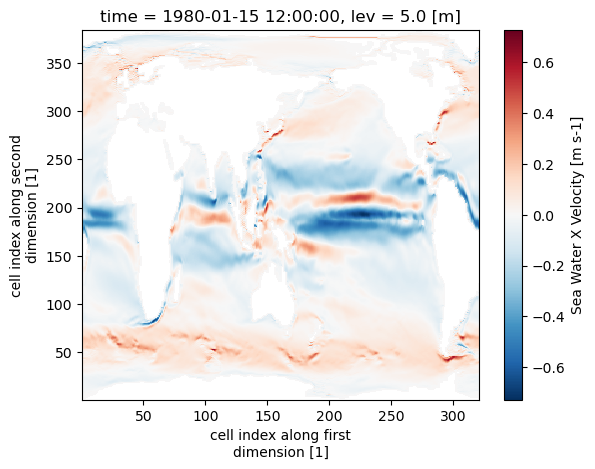

In [29]:
ds_uv.uo.isel(time=0, lev=0).plot()

<a id='section4'></a>
## Section 4: Results Visualization

Reference bias plots: model (`ds_target`) vs OMIP (`ds_model`) vs obs (`ds_obs`).

### Load OMIP comparison dataset

Path is hardcoded in `natl_driver.py:183` — Brendan's archive on `/glade/work/brendanmy/`. Select `OMIP=0` (first iteration) to match the driver.

In [60]:
omip_file = '/glade/work/brendanmy/S_Yeager/Sub2Sub/data_archive/POD_data/omip2.cycle1.1989_2018.0-200m.mld_sic_t_s_sigma.nc'
ds_model = xr.open_dataset(omip_file).isel(OMIP=0).load()
print('OMIP vars:', list(ds_model.data_vars))
print('OMIP dims:', dict(ds_model.sizes))

OMIP vars: ['mld', 'thetao_zavg', 'so_zavg', 'sigma0_zavg', 'sic']
OMIP dims: {'month': 12, 'model': 16, 'lat': 180, 'lon': 360}


### Bias maps vs obs (θ, S, σ₀, MLD)

Each call to `POD_utils.SpatialPlot_climo_bias` produces a two-panel bias map for one variable. Returned datasets `ds_t200` and `ds_s200` hold the θ and S bias fields used by the scatter plot below.

<xarray.Dataset> Size: 3kB
Dimensions:   (lon: 90, lat: 60, model: 17)
Coordinates:
  * lon       (lon) float64 720B 270.5 271.5 272.5 273.5 ... 357.5 358.5 359.5
  * lat       (lat) float64 480B 20.5 21.5 22.5 23.5 ... 76.5 77.5 78.5 79.5
  * model     (model) <U25 2kB 'TaiESM1-TIMCOM' ... 'CESM2_historical_r1i1p1f1'
    cycle     int64 8B 1
    OMIP      <U1 4B '2'
Data variables:
    mld_bias  (model) float64 136B -35.67 -16.5 -12.34 ... -20.67 -20.21 12.56
    mld_rmse  (model) float64 136B 36.92 31.81 50.63 143.5 ... 31.27 46.67 104.1

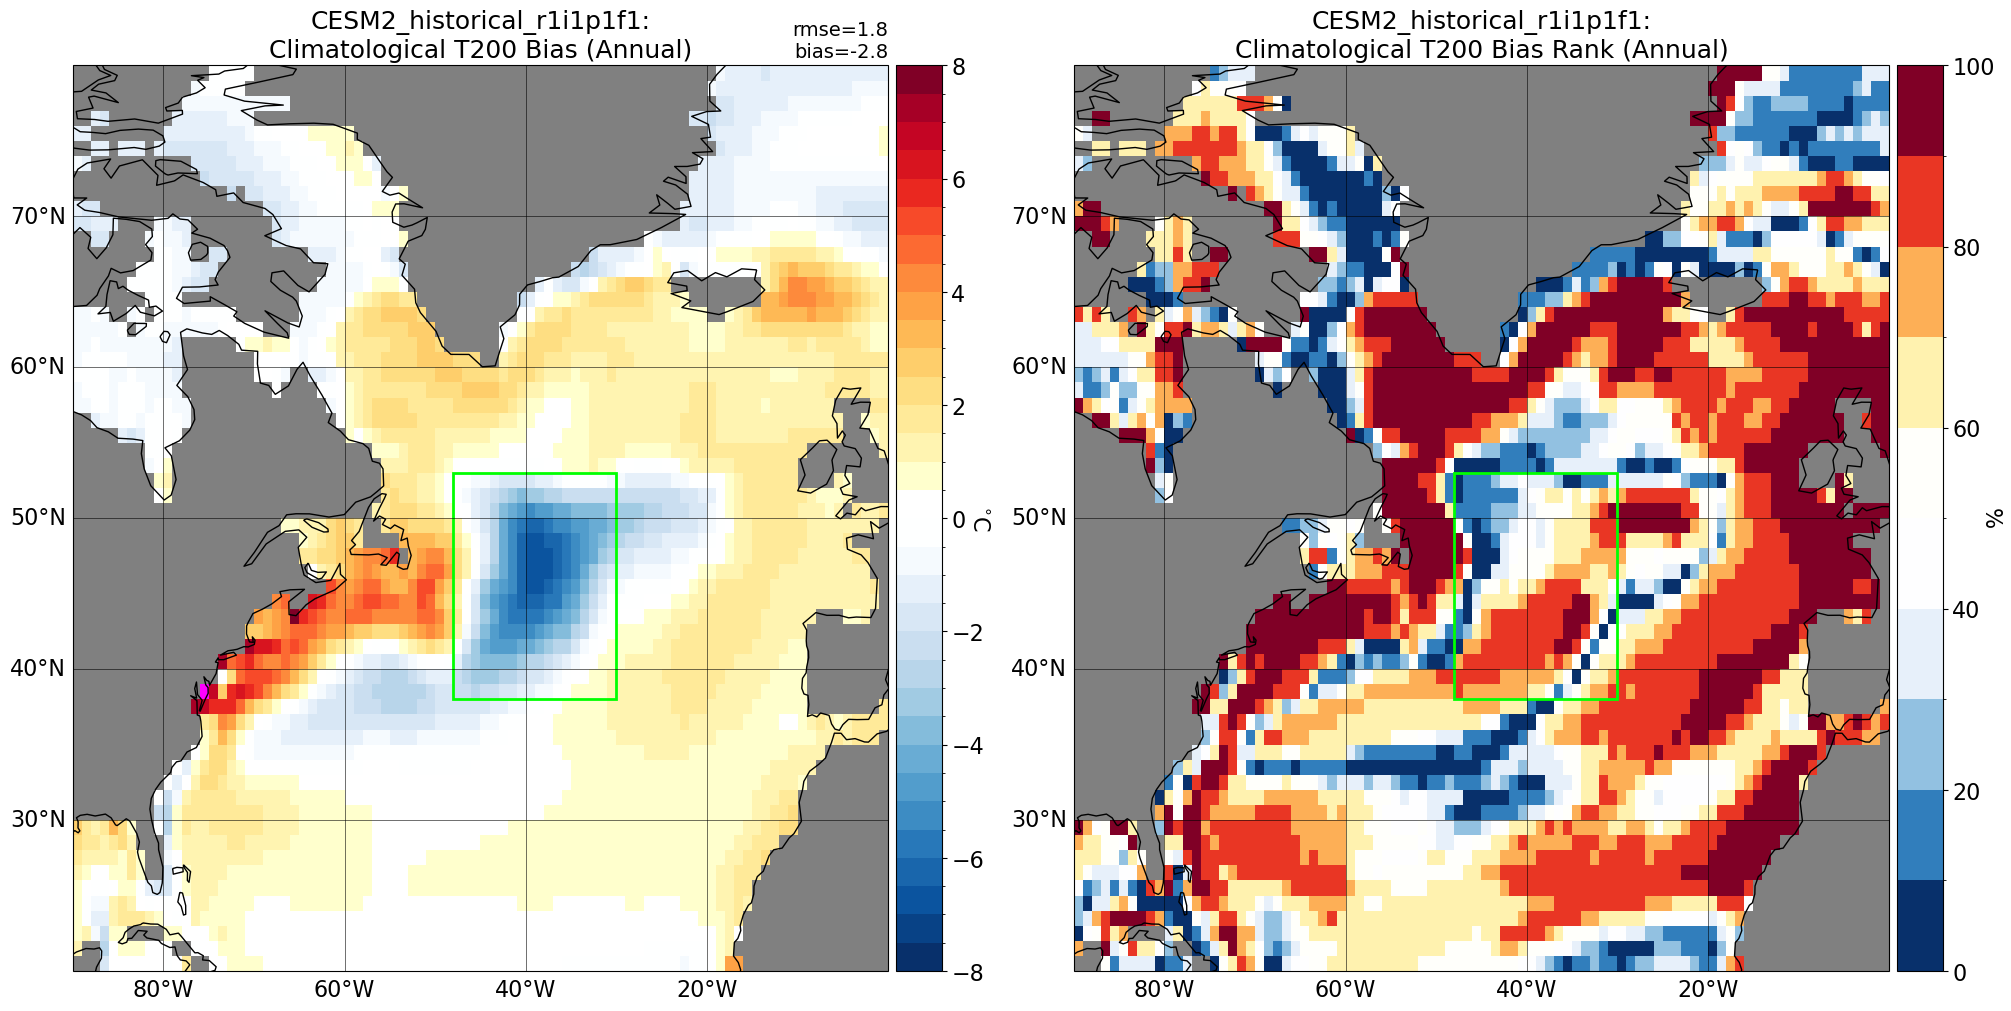

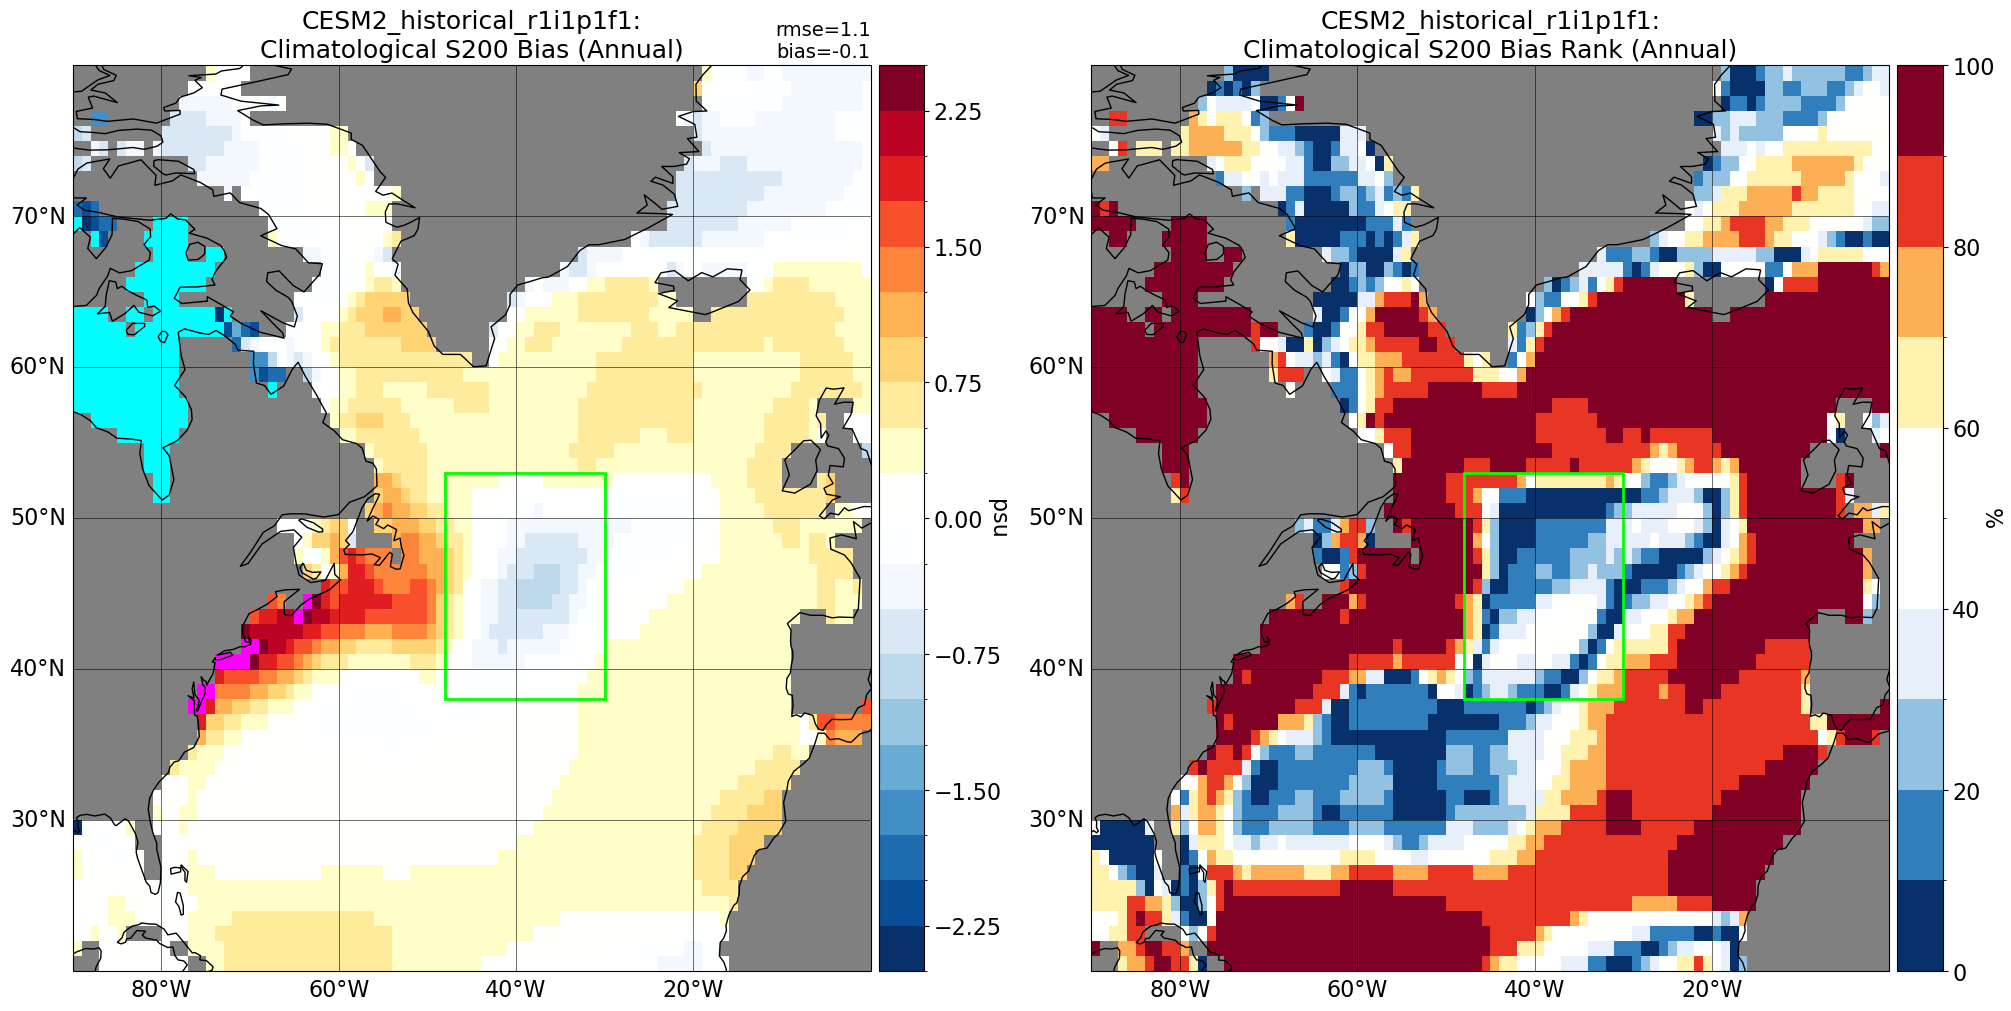

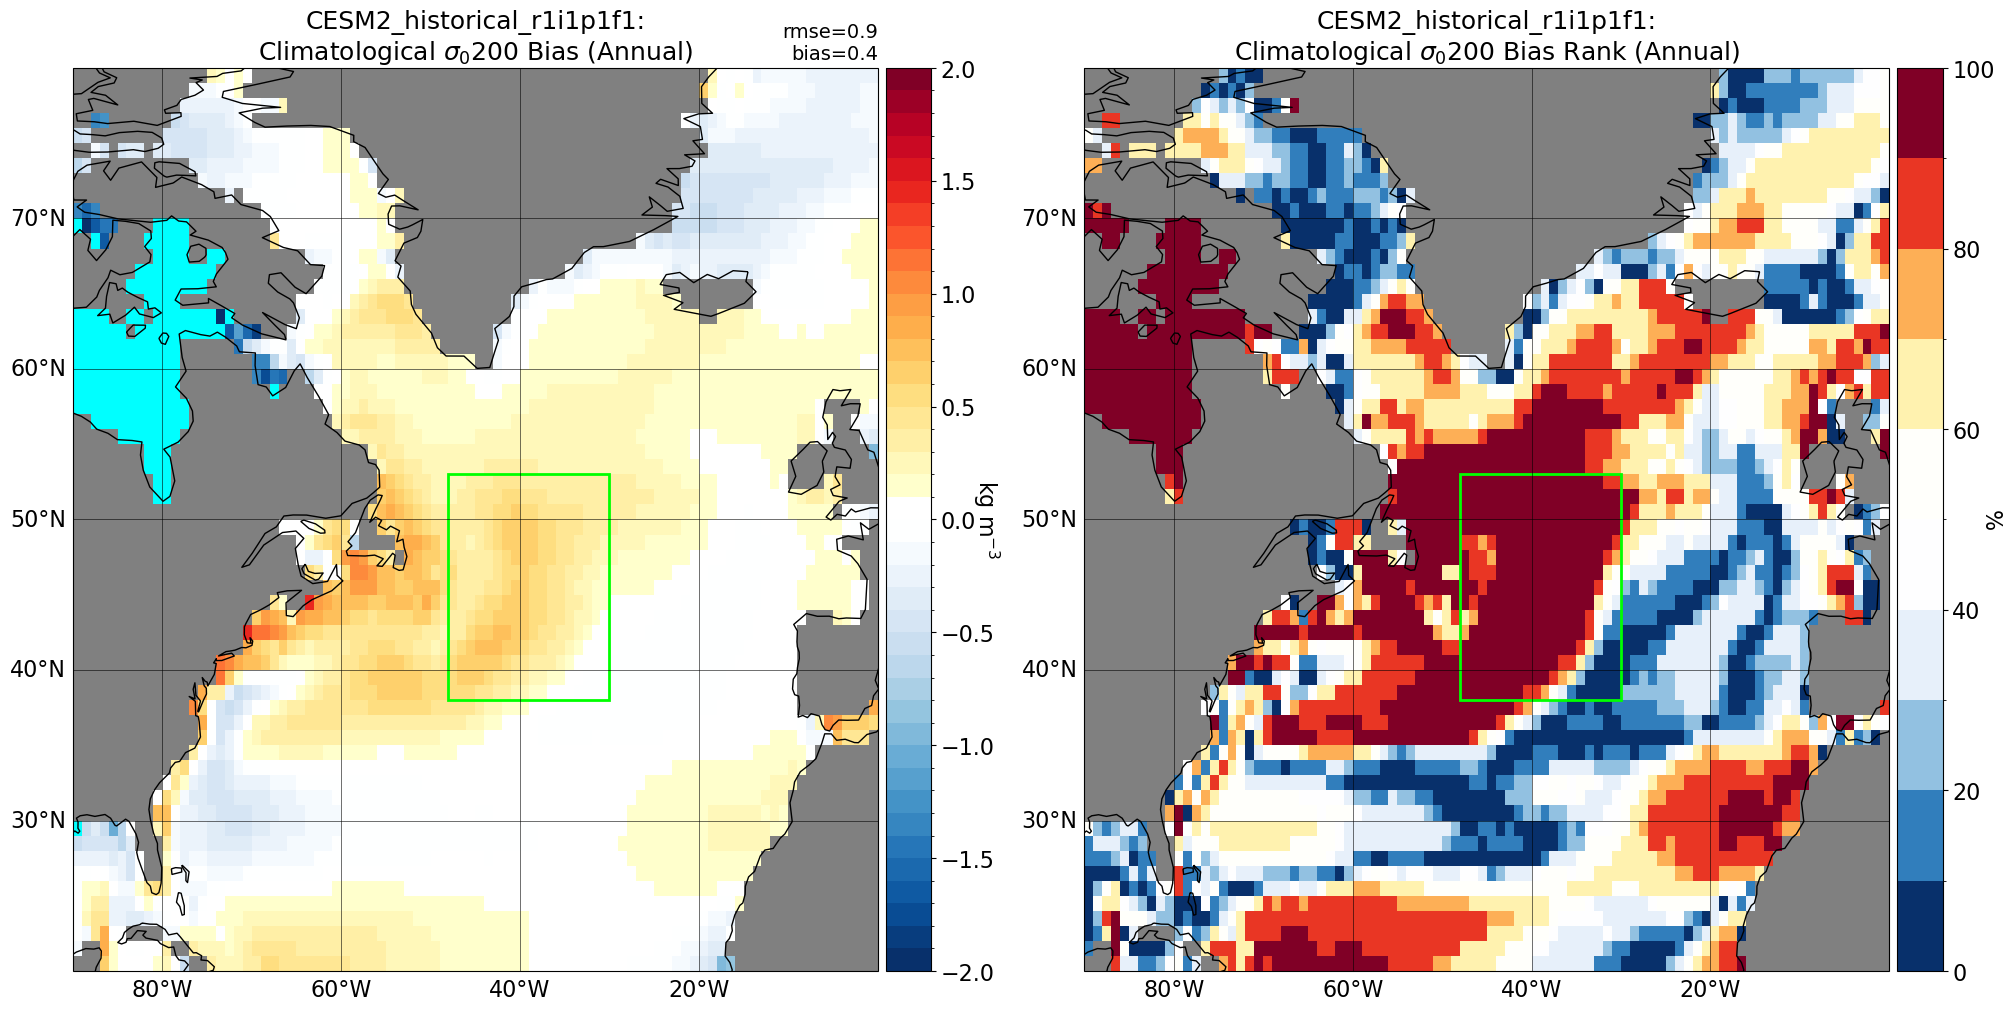

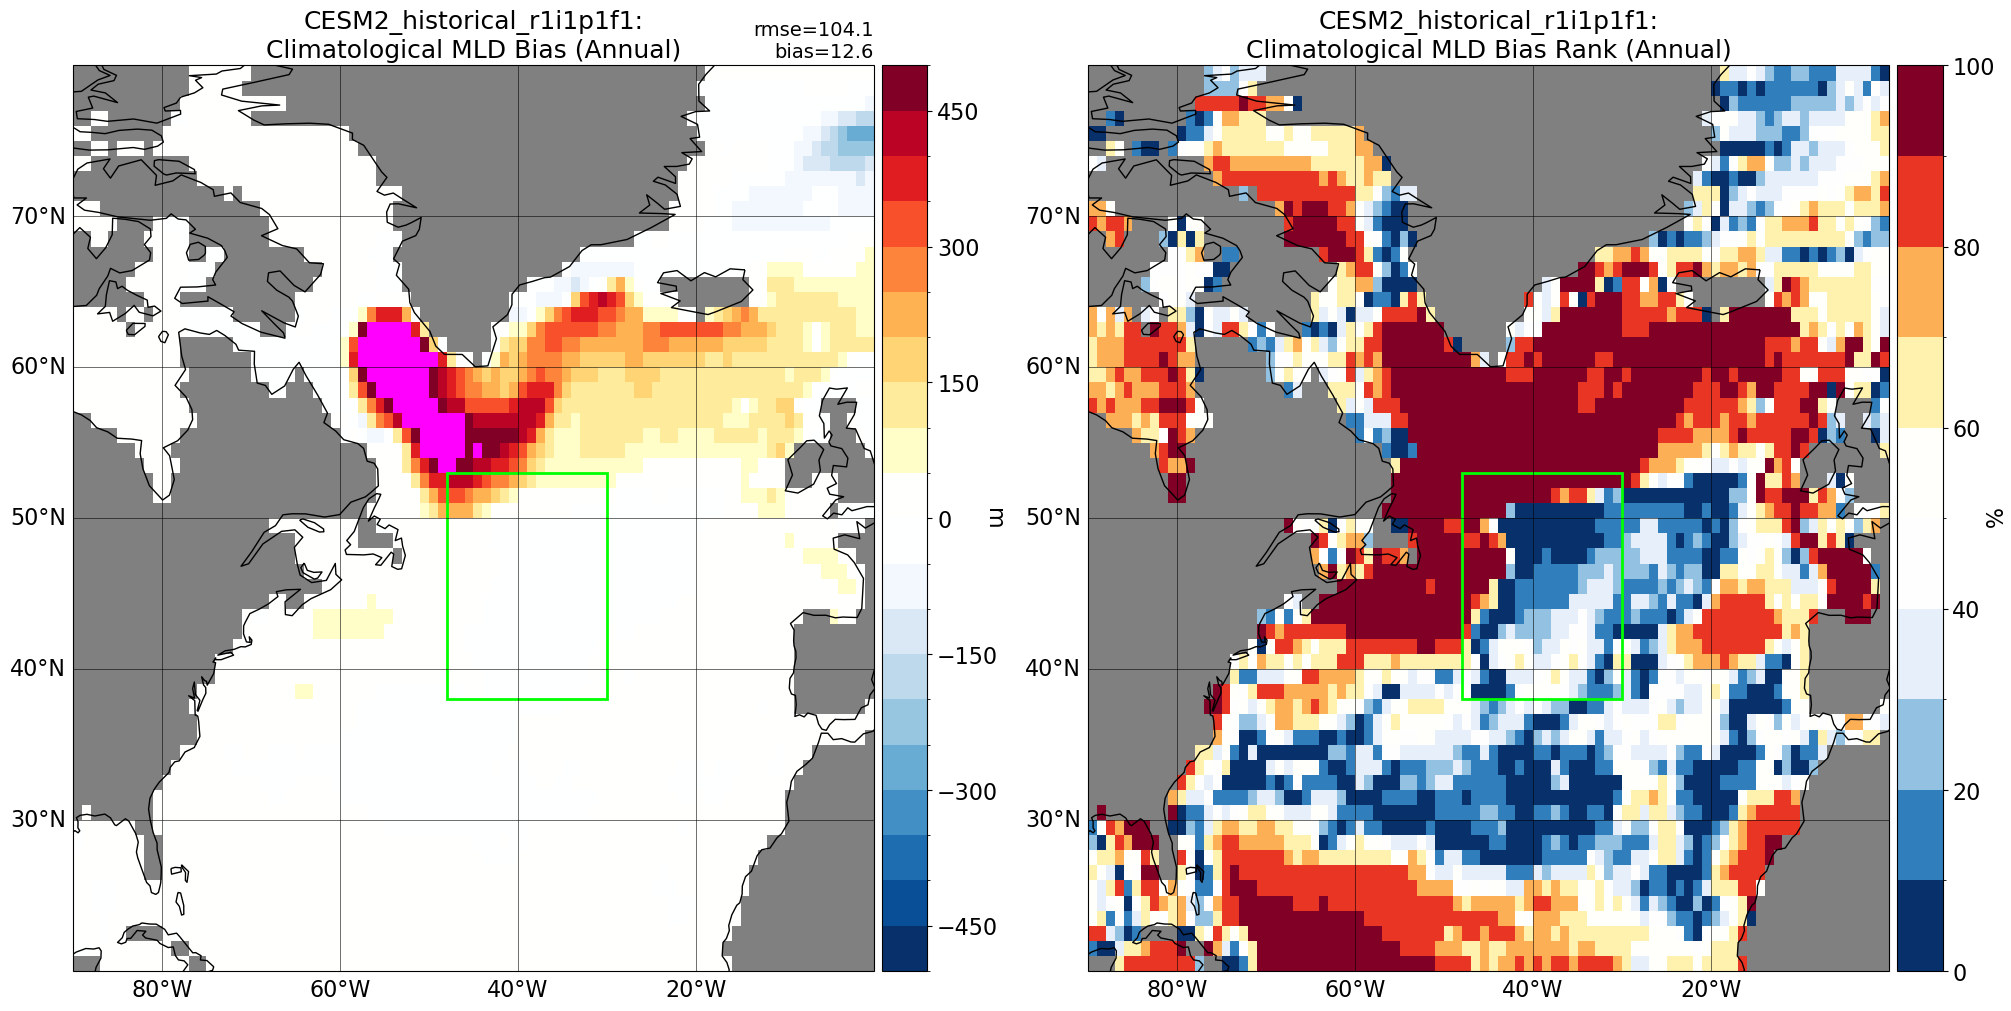

In [61]:
outmod_dir = os.path.join(os.environ['WORK_DIR'], 'model')
Path(outmod_dir).mkdir(parents=True, exist_ok=True)

region = opts['plot_region']
focus  = opts['focus_region']
month  = opts['plot_month']

ds_t200 = POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'thetao_zavg',
                                          region=region, focus_region=focus, month=month,
                                          save=False, savedir=outmod_dir)
ds_s200 = POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'so_zavg',
                                          region=region, focus_region=focus, month=month,
                                          save=False, savedir=outmod_dir)
POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'sigma0_zavg',
                                 region=region, focus_region=focus, month=month,
                                 save=False, savedir=outmod_dir)
POD_utils.SpatialPlot_climo_bias(ds_target, ds_model, ds_obs, 'mld',
                                 region=region, focus_region=focus, month=month,
                                 save=False, savedir=outmod_dir)

### Scatter plot of θ vs S biases

Compact summary of where θ and S biases are large together.

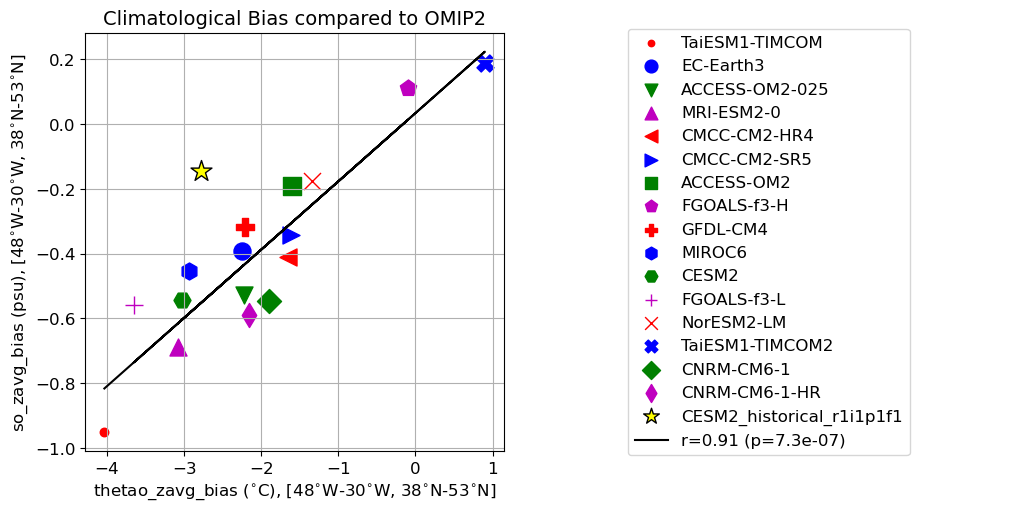

In [62]:
POD_utils.ScatterPlot_Error(
    ds_t200, 'thetao_zavg_bias',
    ds_s200, 'so_zavg_bias',
    model_name,
    save=False, savedir=outmod_dir,
)

### WMT lines vs OMIP benchmarks (by region)

Compare modeled surface-forced WMT against observation-based decomposed benchmarks (`obs_wmt_sigma2_1982-2009_spna_decomp_mean.nc`).

WMT benchmark vars: ['heat', 'wmt', 'freshwater']


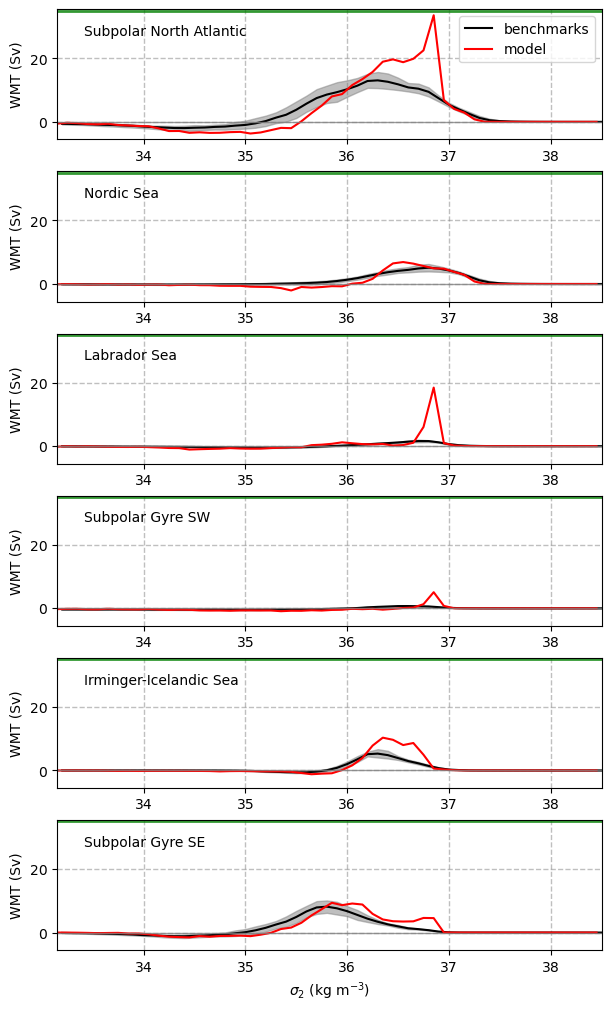

In [63]:
ds_wmt_benchmarks = xr.open_dataset(
    os.path.join(os.environ['OBS_DATA'], 'obs_wmt_sigma2_1982-2009_spna_decomp_mean.nc')
)
print('WMT benchmark vars:', list(ds_wmt_benchmarks.data_vars))

POD_utils.wmt_plot_byregion(
    ds_wmt_benchmarks, ds_wmt_lines, sigma_classes,
    save=False, savedir=outmod_dir,
)

### Density-flux maps at specified σ₂ classes

Maps of surface density flux into each water-mass class compared to observation-based decomposed benchmarks (`obs.maps_freq.sigma2.1982-2009_decomp_mean_1x1.nc`).

density-flux benchmark vars: ['heat', 'salt', 'wmt', 'wmt_freq']
correcting lat for dateline


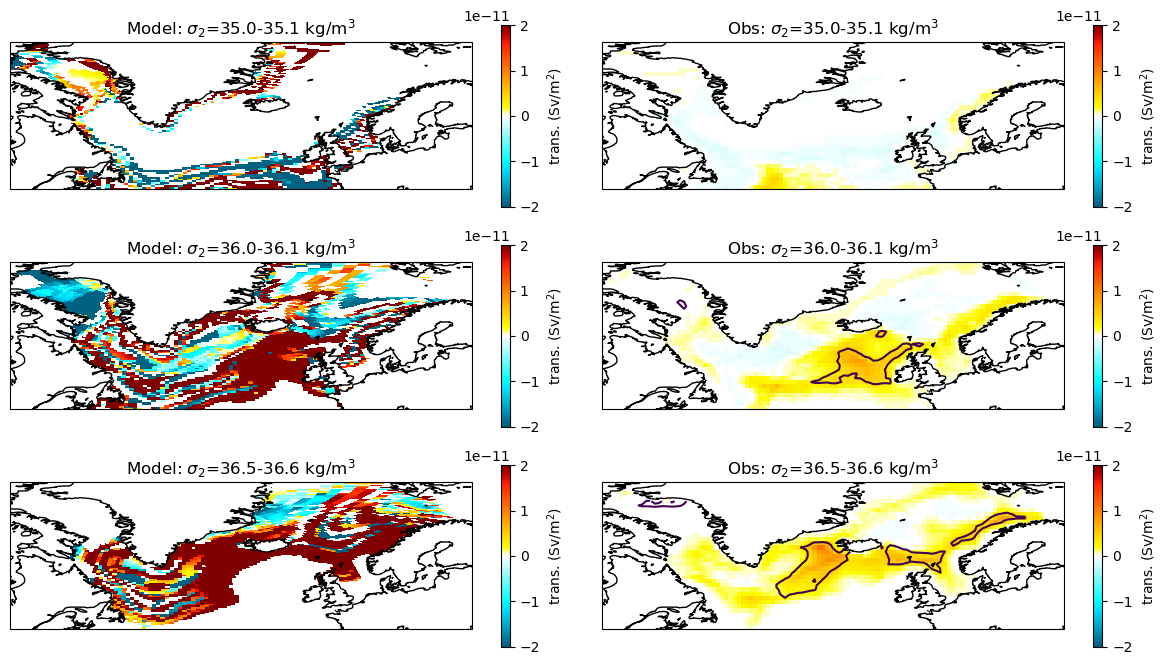

In [64]:
ds_dflux_benchmarks = xr.open_dataset(
    os.path.join(os.environ['OBS_DATA'], 'obs.maps_freq.sigma2.1982-2009_decomp_mean_1x1.nc')
)
print('density-flux benchmark vars:', list(ds_dflux_benchmarks.data_vars))

POD_utils.wmt_plot_maps(
    ds_dflux_benchmarks, ds_wmt_maps,
    ['time', 'x', 'y'],
    sigma_classes,
    save=False, savedir=outmod_dir,
)

- Check density contour for model

### Risks / fallbacks

**Bias-plot path (Section 4 first half):**
- **`POD_utils.preprocess_coords`** may rename `nlat`/`nlon` to other names. If downstream   code errors after Step 1, fall back to `ds_target = ds_merged.copy()` (skip the preprocess call).
- **`compute_zavg`** requires `dz` to have `lev` in meters and broadcast against the variable.   If `*_zavg` arrays come back with NaNs or wrong shape, recheck the cm→m conversion and   `dz.assign_coords(lev=...)`.
- **`SpatialPlot_climo_bias`** expects `ds_model` to carry variables named `thetao_zavg`,   `so_zavg`, `sigma0_zavg`, `mld`. The OMIP file's actual var names may differ — inspect   `ds_model.data_vars` after loading and rename with `ds_model = ds_model.rename({...})` if needed.
- **`ScatterPlot_Error`** assumes the bias dataset returned by `SpatialPlot_climo_bias` contains   the `*_bias` fields. If it errors, inspect `ds_t200.data_vars` after the first plot and adjust.

**WMT path (Section 3 Steps 6–7 + Section 4 second half):**
- **xwmt version pin**: `POD_utils.calc_wmt` calls `xwmt.swmt(...)` — that class only exists   in xwmt 0.0.3. xwmt ≥ 0.1.0 replaced it with `WaterMassTransformations`, which has a different   signature. The esnb env is pinned to xwmt 0.0.3 for this reason.
- **Surface-fields shape**: Step 6 builds `ds_target_wmt` independently of the bias-path   `ds_target` (which has been regridded + climatology'd). WMT needs the native-grid time series,   not the climatology.
- **`wmt_plot_maps` dim names**: the third arg expects `[time_coord, lon_coord, lat_coord]`   matching the result of `compute_wmt(..., 'MAPS')`. We pass `['time', 'x', 'y']` since `wmt_preproc`   renames spatial dims. If it errors, inspect `ds_wmt_maps.dims` and adjust the list.
- **xwmt `vsf` handling**: `wmt_preproc` converts `vsf` to `wfo` (the CMIP wfo would have the   opposite sign convention). We feed `vsf` so this branch is exercised.